# HSE Performance Analysis

Pandas reproduction of every KPI in the Excel dashboard, plus the SPC, Pareto and heatmap figures used in the monthly memo.

**Data:** `data/processed/incident_log_clean_SYNTHETIC.csv` - synthetic incident log for one site, Jan 2025 to Jun 2026. Not real incident records.

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import src.config as cfg
import src.kpi as K

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.3})
log = pd.read_csv(cfg.CLEAN_LOG, parse_dates=["date"])
log.head()

,incident_id,date,Shift,Department,Event Type,Body Part,Immediate Cause,Root Cause,Days Lost,Contractor,Month,Year,Recordable,LTI,Near Miss,Has Days Lost
0,INC-0001,2025-01-01,Day,Warehouse,Near Miss,NaN,Equipment Failure,Poor Supervision,0,No,2025-01,2025,False,False,True,False
1,INC-0002,2025-01-03,Night,Maintenance,Near Miss,NaN,Poor Housekeeping,Equipment Maintenance,0,No,2025-01,2025,False,False,True,False
2,INC-0003,2025-01-04,Day,Logistics,Near Miss,NaN,Equipment Failure,Housekeeping Management,0,Yes,2025-01,2025,False,False,True,False
3,INC-0004,2025-01-08,Evening,Warehouse,First Aid,Head,Unsafe Condition,Risk Assessment Gap,0,Yes,2025-01,2025,False,False,False,False
4,INC-0005,2025-01-10,Evening,Production,Near Miss,NaN,Poor Housekeeping,Housekeeping Management,0,No,2025-01,2025,False,False,True,False


## 1. Data overview
Quick profile of the cleaned log.

In [2]:
print(f"rows: {len(log)}, months: {log['Month'].nunique()}, "
      f"departments: {log['Department'].nunique()}")
log["Event Type"].value_counts()

rows: 337, months: 18, departments: 4


Event Type
Near Miss            276
First Aid             39
Medical Treatment     16
Lost Time Injury       6
Name: count, dtype: int64

## 2. Monthly KPI reproduction
Same formulas as the Excel dashboard:

- **LTIF** = lost time injuries x 1,000,000 / man-hours
- **TRIR** = recordables x 200,000 / man-hours
- **Severity rate** = days lost x 1,000,000 / man-hours
- **Near-miss ratio** = near misses / total events x 100

In [3]:
kpi = K.kpis_by_month(log)
kpi.head(6)

,Month,Phase,Man-Hours,Near Miss,First Aid,Medical Treatment,Lost Time Injury,Recordables,Total Incidents,Days Lost,Inspections,LTIF,TRIR,Severity Rate,Near Miss Ratio,RAG TRIR,RAG LTIF,RAG Severity,RAG Near Miss
0,2025-01,Improvement,92000.0,19,1,2,0,2,22,0,60,0.000000,4.347826,0.000000,86.363636,Red,Green,Green,Green
1,2025-02,Improvement,80000.0,14,3,0,0,0,17,0,63,0.000000,0.000000,0.000000,82.352941,Green,Green,Green,Green
2,2025-03,Improvement,84000.0,18,4,1,1,2,24,1,60,11.904762,4.761905,11.904762,75.000000,Red,Red,Green,Amber
3,2025-04,Improvement,88000.0,17,2,0,1,1,20,3,44,11.363636,2.272727,34.090909,85.000000,Green,Red,Red,Green
4,2025-05,Improvement,88000.0,13,1,2,0,2,16,0,51,0.000000,4.545455,0.000000,81.250000,Red,Green,Green,Green
5,2025-06,Improvement,84000.0,9,1,0,0,0,10,0,57,0.000000,0.000000,0.000000,90.000000,Green,Green,Green,Green


In [4]:
cols = ["Month", "Man-Hours", "Near Miss", "Recordables",
        "Lost Time Injury", "Days Lost", "LTIF", "TRIR", "Severity Rate"]
kpi[cols].round(2)

,Month,Man-Hours,Near Miss,Recordables,Lost Time Injury,Days Lost,LTIF,TRIR,Severity Rate
0,2025-01,92000.0,19,2,0,0,0.00,4.35,0.00
1,2025-02,80000.0,14,0,0,0,0.00,0.00,0.00
2,2025-03,84000.0,18,2,1,1,11.90,4.76,11.90
3,2025-04,88000.0,17,1,1,3,11.36,2.27,34.09
4,2025-05,88000.0,13,2,0,0,0.00,4.55,0.00
5,2025-06,84000.0,9,0,0,0,0.00,0.00,0.00
6,2025-07,92000.0,12,2,0,0,0.00,4.35,0.00
7,2025-08,84000.0,20,2,2,8,23.81,4.76,95.24
8,2025-09,88000.0,23,5,2,9,22.73,11.36,102.27
9,2025-10,92000.0,19,1,0,0,0.00,2.17,0.00


## 3. Trend chart with targets

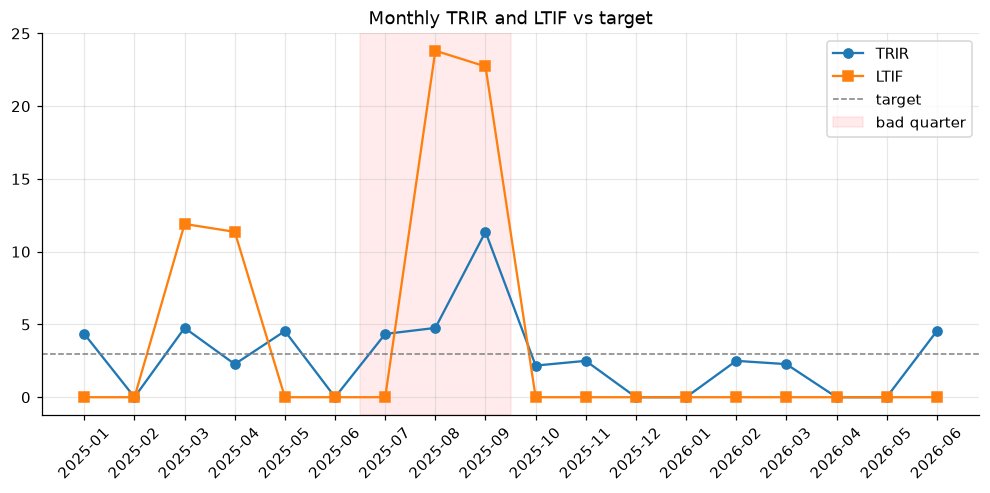

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(kpi["Month"], kpi["TRIR"], marker="o", label="TRIR")
ax.plot(kpi["Month"], kpi["LTIF"], marker="s", label="LTIF")
ax.axhline(cfg.TARGETS["TRIR"], ls="--", lw=1, color="grey", label="target")
ax.axvspan(5.5, 8.5, color="red", alpha=0.08, label="bad quarter")
ax.set_title("Monthly TRIR and LTIF vs target")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.show()

## 4. SPC control chart on TRIR
Mean + 2-sigma limits answer: **is the bad quarter a real signal or noise?** Points outside the limits (or long runs) suggest a special cause.

mean=2.80  sigma=2.79  UCL=8.38  LCL=0.00


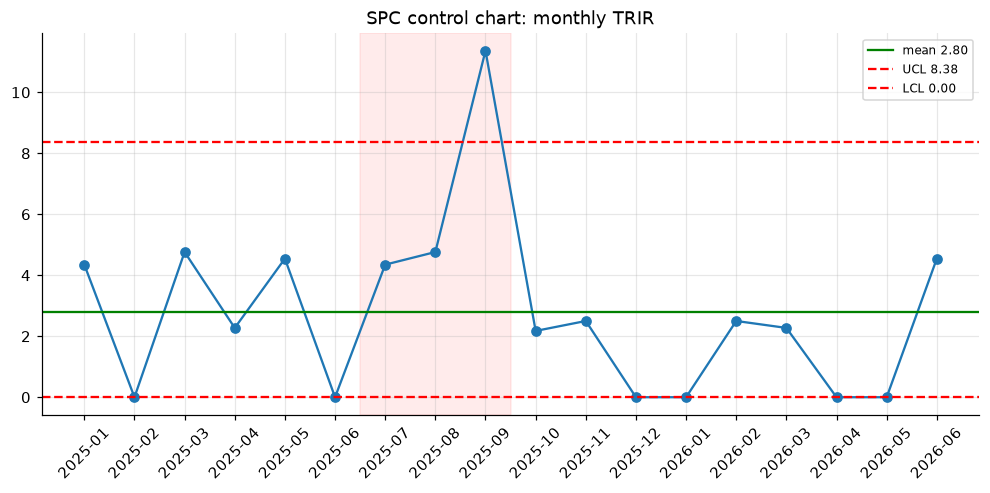

Months above UCL: [('2025-09', np.float64(11.36))]


In [6]:
values = kpi["TRIR"].to_numpy(float)
mean, sigma = values.mean(), values.std(ddof=0)
ucl, lcl = mean + 2 * sigma, max(mean - 2 * sigma, 0)
print(f"mean={mean:.2f}  sigma={sigma:.2f}  UCL={ucl:.2f}  LCL={lcl:.2f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(kpi["Month"], values, marker="o")
ax.axhline(mean, color="green", label=f"mean {mean:.2f}")
ax.axhline(ucl, color="red", ls="--", label=f"UCL {ucl:.2f}")
ax.axhline(lcl, color="red", ls="--", label=f"LCL {lcl:.2f}")
ax.axvspan(5.5, 8.5, color="red", alpha=0.08)
ax.set_title("SPC control chart: monthly TRIR")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper right", fontsize=8)
plt.show()

out = [(str(m), round(v, 2)) for m, v in zip(kpi["Month"], values) if v > ucl]
print("Months above UCL:", out if out else "none")

## 5. Department Pareto

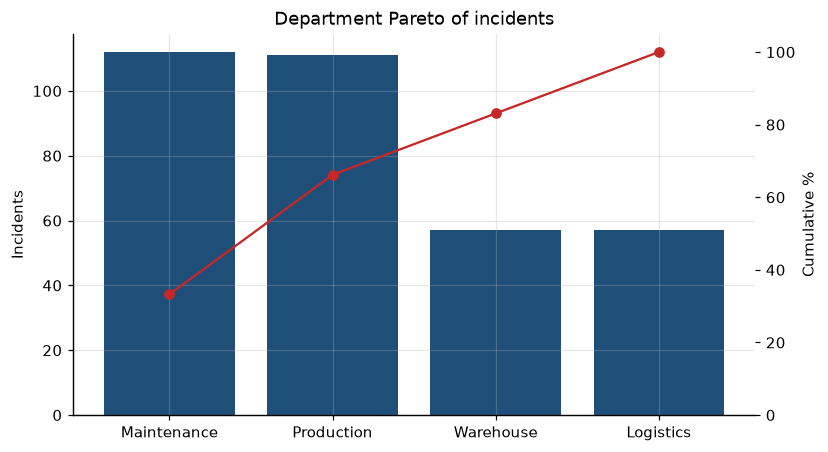

,incidents,cum_pct
Department,,
Maintenance,112,33.2
Production,111,66.2
Warehouse,57,83.1
Logistics,57,100.0


In [7]:
counts = log["Department"].value_counts()
cum = counts.cumsum() * 100 / counts.sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(counts.index, counts.values, color="#1f4e79")
ax2 = ax.twinx()
ax2.plot(counts.index, cum.values, marker="o", color="#c62828")
ax2.set_ylim(0, 105)
ax2.grid(False)
ax.set_title("Department Pareto of incidents")
ax.set_ylabel("Incidents")
ax2.set_ylabel("Cumulative %")
plt.show()

pd.DataFrame({"incidents": counts, "cum_pct": cum.round(1)})

## 6. Department x event-type heatmap
Maintenance should dominate equipment-related serious events, especially in the bad quarter.

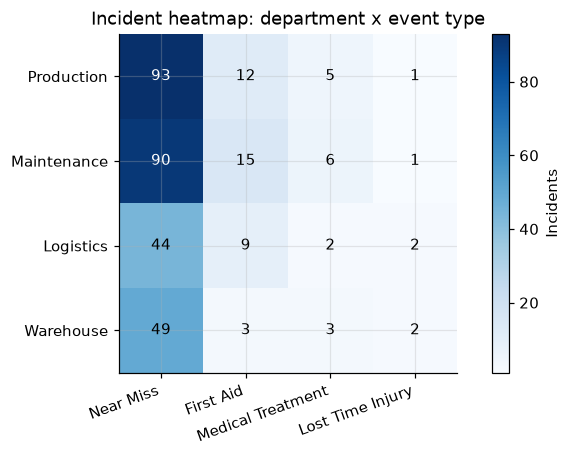

Bad quarter recordables by department:
Department
Logistics      2
Maintenance    4
Production     1
Warehouse      2
dtype: int64


In [8]:
table = pd.crosstab(log["Department"], log["Event Type"]).reindex(
    index=cfg.DEPARTMENTS, columns=cfg.EVENT_TYPES)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(table.values, cmap="Blues")
ax.set_xticks(range(len(table.columns)), table.columns, rotation=20, ha="right")
ax.set_yticks(range(len(table.index)), table.index)
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        ax.text(j, i, table.iloc[i, j], ha="center", va="center",
                color="white" if table.iloc[i, j] > table.values.max() * 0.6 else "black")
fig.colorbar(im, ax=ax, label="Incidents")
ax.set_title("Incident heatmap: department x event type")
plt.show()

bad = log[log["Month"].isin(["2025-07", "2025-08", "2025-09"])]
print("Bad quarter recordables by department:")
print(bad[bad["Recordable"]].groupby("Department").size())

## 7. Parity check: notebook vs pipeline
The notebook must reproduce the pipeline's monthly KPI table exactly.

In [9]:
pipeline = pd.read_csv(cfg.MONTHLY_KPI_FILE)
check = kpi.drop(columns=["RAG TRIR", "RAG LTIF", "RAG Severity", "RAG Near Miss"])
match = np.allclose(check.select_dtypes("number"),
                    pipeline[check.select_dtypes("number").columns])
assert match, "KPI table does not match the pipeline output"
print("Parity check PASSED: notebook KPIs == pipeline KPIs")

Parity check PASSED: notebook KPIs == pipeline KPIs


## 8. YTD summary and worst department
Latest-month YTD view, as used in the memo.

In [10]:
ytd = K.ytd_summary(kpi)
print({k: round(v, 2) if isinstance(v, float) else v for k, v in ytd.items()})

dept = K.kpis_by_department_month(log)
worst, table = K.worst_department(dept, ytd["year"])
print(f"\nWorst department by YTD TRIR: {worst}")
table.round(2)

{'year': '2026', 'month': '2026-06', 'man_hours': 516000.0, 'lti': 0, 'recordables': 4, 'near_miss': 83, 'total': 101, 'days_lost': 0, 'ltif': 0.0, 'trir': 1.55, 'severity': 0.0, 'near_miss_ratio': 82.18, 'inspections': 271}

Worst department by YTD TRIR: Warehouse


,Recordables,ManHours,TRIR
Department,,,
Logistics,1,82560.0,2.42
Maintenance,1,134160.0,1.49
Production,1,227040.0,0.88
Warehouse,1,72240.0,2.77
